<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/work/10_qsvm_performance_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day26 QSVM 성능 평가 실습

- Source: Google Drive `Day26/4-1.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. 데이터 준비
Train : (80, 4)
Test  : (20, 4)

STEP 2. Classical SVM
Training Complete

STEP 3. QSVM


/var/folders/yx/hh120pwn38g8vm2l1gsljd640000gn/T/ipykernel_71175/2080341107.py:92: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


Training Complete

STEP 4. Prediction


Prediction Complete

STEP 5. Performance Evaluation

 Classical SVM
------------------------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


 QSVM
------------------------------------------------------------
Accuracy : 0.9000
Precision: 0.9000
Recall   : 0.9000
F1 Score : 0.9000

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg

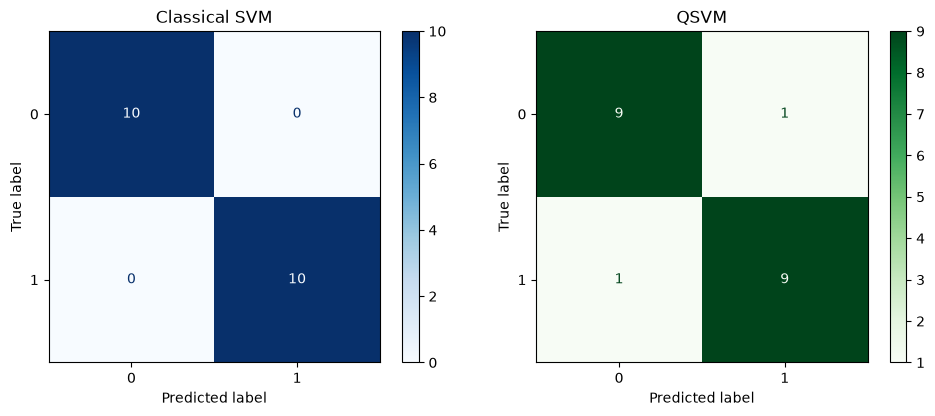


STEP 7. Performance Comparison
            Metric  Classical SVM       QSVM
0         Accuracy       1.000000   0.900000
1        Precision       1.000000   0.900000
2           Recall       1.000000   0.900000
3         F1 Score       1.000000   0.900000
4    Training Time       0.001196  14.435428
5  Prediction Time       0.000724   6.070222

STEP 8. Result Analysis
1. Accuracy 비교
Classical SVM Accuracy가 더 높습니다.

2. Training Time
Classical : 0.0012 sec
QSVM      : 14.4354 sec

3. Prediction Time
Classical : 0.0007 sec
QSVM      : 6.0702 sec

Lab Complete


In [1]:
# ============================================================
# Lab. QSVM Performance Evaluation
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# ============================================================
# Quantum
# ============================================================

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# ============================================================
# STEP 1. 데이터 준비
# ============================================================

print("="*80)
print("STEP 1. 데이터 준비")
print("="*80)

iris = load_iris()

X = iris.data
y = iris.target

# Binary Classification
X = X[y != 2]
y = y[y != 2]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# ============================================================
# STEP 2. Classical SVM 생성 및 학습
# ============================================================

print("\n"+"="*80)
print("STEP 2. Classical SVM")
print("="*80)

classical_svm = SVC(kernel="rbf")

start = time.perf_counter()

classical_svm.fit(X_train, y_train)

classical_train_time = time.perf_counter() - start

print("Training Complete")

# ============================================================
# STEP 3. QSVM 생성 및 학습
# ============================================================

print("\n"+"="*80)
print("STEP 3. QSVM")
print("="*80)

feature_map = ZZFeatureMap(
    feature_dimension=X.shape[1],
    reps=2
)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

qsvm = QSVC(
    quantum_kernel=quantum_kernel
)

start = time.perf_counter()

qsvm.fit(X_train, y_train)

qsvm_train_time = time.perf_counter() - start

print("Training Complete")

# ============================================================
# STEP 4. Prediction
# ============================================================

print("\n"+"="*80)
print("STEP 4. Prediction")
print("="*80)

start = time.perf_counter()
y_pred_classical = classical_svm.predict(X_test)
classical_predict_time = time.perf_counter()-start

start = time.perf_counter()
y_pred_qsvm = qsvm.predict(X_test)
qsvm_predict_time = time.perf_counter()-start

print("Prediction Complete")

# ============================================================
# STEP 5. Evaluation Function
# ============================================================

print("\n"+"="*80)
print("STEP 5. Performance Evaluation")
print("="*80)

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true,y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="binary"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="binary"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="binary"
    )

    print("\n",name)
    print("-"*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    return {
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1":f1
    }

classical_result = evaluate_model(
    "Classical SVM",
    y_test,
    y_pred_classical
)

qsvm_result = evaluate_model(
    "QSVM",
    y_test,
    y_pred_qsvm
)

# ============================================================
# STEP 6. Confusion Matrix
# ============================================================

print("\n"+"="*80)
print("STEP 6. Confusion Matrix")
print("="*80)

fig, axes = plt.subplots(1,2,figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_classical,
    ax=axes[0],
    cmap="Blues"
)

axes[0].set_title("Classical SVM")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_qsvm,
    ax=axes[1],
    cmap="Greens"
)

axes[1].set_title("QSVM")

plt.tight_layout()
plt.show()

# ============================================================
# STEP 7. Performance Comparison
# ============================================================

print("\n"+"="*80)
print("STEP 7. Performance Comparison")
print("="*80)

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Prediction Time"
    ],

    "Classical SVM":[

        classical_result["Accuracy"],
        classical_result["Precision"],
        classical_result["Recall"],
        classical_result["F1"],
        classical_train_time,
        classical_predict_time
    ],

    "QSVM":[

        qsvm_result["Accuracy"],
        qsvm_result["Precision"],
        qsvm_result["Recall"],
        qsvm_result["F1"],
        qsvm_train_time,
        qsvm_predict_time

    ]

})

print(comparison)

# ============================================================
# STEP 8. Result Analysis
# ============================================================

print("\n"+"="*80)
print("STEP 8. Result Analysis")
print("="*80)

print("1. Accuracy 비교")

if qsvm_result["Accuracy"] > classical_result["Accuracy"]:
    print("QSVM Accuracy가 더 높습니다.")
else:
    print("Classical SVM Accuracy가 더 높습니다.")

print()

print("2. Training Time")

print(f"Classical : {classical_train_time:.4f} sec")
print(f"QSVM      : {qsvm_train_time:.4f} sec")

print()

print("3. Prediction Time")

print(f"Classical : {classical_predict_time:.4f} sec")
print(f"QSVM      : {qsvm_predict_time:.4f} sec")

print()


print("="*80)
print("Lab Complete")
print("="*80)